In [ ]:

%load_ext autoreload
%autoreload 2

In [1]:
# Import required libraries
import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.ticker import AutoMinorLocator, FuncFormatter, MaxNLocator, MultipleLocator
from pathlib import Path
import seaborn as sns
from src.config.path import SRC_DIR, RESULTS_DIR, HAMNUCRET_DATA_DIR
# Configure matplotlib for better plots
mpl.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 12,
    'axes.labelsize': 14,
    'axes.labelweight': 'bold',
    'axes.titlesize': 16,
    'axes.titleweight': 'bold',
    'figure.dpi': 100,
    'savefig.dpi': 300,
})

print("✓ Libraries imported successfully")

Source Directory: /home/pol_schiessel/maya620d/pol/Projects/Codebase/Spermatogensis
Output Directory: /home/pol_schiessel/maya620d/pol/Projects/Codebase/Spermatogensis
HAMNUCRET Data Directory: /home/pol_schiessel/maya620d/pol/Projects/Codebase/Spermatogensis/hamnucret_data
✓ Libraries imported successfully


## 1. Setup Paths and Load Data

In [3]:
# Define paths
BASE_DIR = Path("/home/pol_schiessel/maya620d/pol/Projects/Codebase/Spermatogensis")
OUTPUT_DIR = RESULTS_DIR / "local_tests" / "with_protamine"

# List all files
print("Available files:")
for f in sorted(OUTPUT_DIR.glob("*")):
    size_mb = f.stat().st_size / (1024**2)
    print(f"  {f.name:<40} {size_mb:>8.2f} MB")

Available files:
  EVI_001_summary.tsv                          0.00 MB
  EVI_001_trajectories.parquet                 0.02 MB
  RET_001_summary.tsv                          0.00 MB
  RET_001_trajectories.parquet                 0.02 MB
  figures                                      0.00 MB


In [4]:
# Load summary TSV files
ret_summary = pl.read_csv(OUTPUT_DIR / "RET_001_summary.tsv", separator='\t')
evi_summary = pl.read_csv(OUTPUT_DIR / "EVI_001_summary.tsv", separator='\t')

print("RET Summary:")
print(ret_summary.describe())
print("\nEVI Summary:")
print(evi_summary.describe())

RET Summary:
shape: (9, 7)
┌────────────┬───────────────┬───────────┬──────────────┬──────────────┬───────────┬───────────────┐
│ statistic  ┆ id            ┆ subid     ┆ n_replicates ┆ avg_cs_total ┆ avg_bprot ┆ avg_detach_ti │
│ ---        ┆ ---           ┆ ---       ┆ ---          ┆ ---          ┆ ---       ┆ me            │
│ str        ┆ str           ┆ f64       ┆ f64          ┆ f64          ┆ f64       ┆ ---           │
│            ┆               ┆           ┆              ┆              ┆           ┆ str           │
╞════════════╪═══════════════╪═══════════╪══════════════╪══════════════╪═══════════╪═══════════════╡
│ count      ┆ 20            ┆ 20.0      ┆ 20.0         ┆ 20.0         ┆ 20.0      ┆ 20            │
│ null_count ┆ 0             ┆ 0.0       ┆ 0.0          ┆ 0.0          ┆ 0.0       ┆ 0             │
│ mean       ┆ null          ┆ 2029.8    ┆ 10.0         ┆ 7.625        ┆ 6.135     ┆ null          │
│ std        ┆ null          ┆ 13.767238 ┆ 0.0          ┆ 4.4064

In [5]:
# Load trajectory Parquet files
ret_traj = pl.read_parquet(OUTPUT_DIR / "RET_001_trajectories.parquet")
evi_traj = pl.read_parquet(OUTPUT_DIR / "EVI_001_trajectories.parquet")

print("RET Trajectories:")
print(f"  Shape: {ret_traj.shape}")
print(f"  Columns: {ret_traj.columns}")
print(f"  Unique nucleosomes: {ret_traj['id'].n_unique()}")
print(f"  Replicates per nucleosome: {ret_traj.group_by(['id', 'subid']).count()['count'].max()}")

print("\nEVI Trajectories:")
print(f"  Shape: {evi_traj.shape}")
print(f"  Columns: {evi_traj.columns}")
print(f"  Unique nucleosomes: {evi_traj['id'].n_unique()}")

RET Trajectories:
  Shape: (200, 7)
  Columns: ['id', 'subid', 'replicate', 'tau_time', 'cs_total', 'bprot', 'detached_total']
  Unique nucleosomes: 20
  Replicates per nucleosome: 10

EVI Trajectories:
  Shape: (200, 7)
  Columns: ['id', 'subid', 'replicate', 'tau_time', 'cs_total', 'bprot', 'detached_total']
  Unique nucleosomes: 10


/tmp/ipykernel_2893792/319714922.py:9: DeprecationWarning: `GroupBy.count` was renamed; use `GroupBy.len` instead
  print(f"  Replicates per nucleosome: {ret_traj.group_by(['id', 'subid']).count()['count'].max()}")


## 2. Summary Statistics Analysis

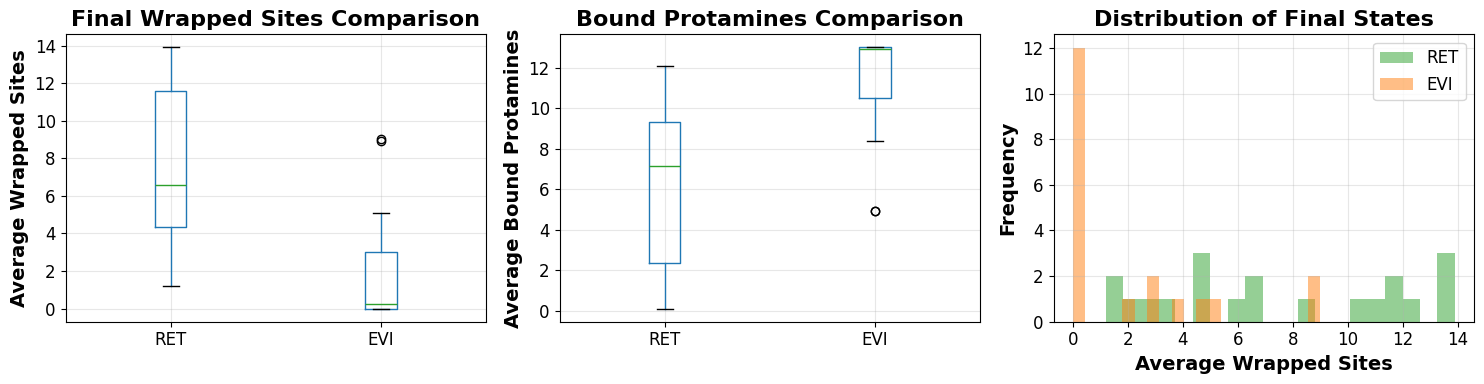

RET - Mean wrapped sites: 7.62 ± 4.41
EVI - Mean wrapped sites: 1.98 ± 2.91


In [6]:
# Compare average wrapped sites between RET and EVI
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Plot 1: Average wrapped sites
ax = axes[0]
data_cs = pd.DataFrame({
    'RET': ret_summary['avg_cs_total'].to_numpy(),
    'EVI': evi_summary['avg_cs_total'].to_numpy()
})
data_cs.boxplot(ax=ax)
ax.set_ylabel('Average Wrapped Sites')
ax.set_title('Final Wrapped Sites Comparison')
ax.grid(alpha=0.3)

# Plot 2: Average bound protamines
ax = axes[1]
data_bprot = pd.DataFrame({
    'RET': ret_summary['avg_bprot'].to_numpy(),
    'EVI': evi_summary['avg_bprot'].to_numpy()
})
data_bprot.boxplot(ax=ax)
ax.set_ylabel('Average Bound Protamines')
ax.set_title('Bound Protamines Comparison')
ax.grid(alpha=0.3)

# Plot 3: Histograms
ax = axes[2]
ax.hist(ret_summary['avg_cs_total'].to_numpy(), bins=20, alpha=0.5, label='RET', color='tab:green')
ax.hist(evi_summary['avg_cs_total'].to_numpy(), bins=20, alpha=0.5, label='EVI', color='tab:orange')
ax.set_xlabel('Average Wrapped Sites')
ax.set_ylabel('Frequency')
ax.set_title('Distribution of Final States')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"RET - Mean wrapped sites: {ret_summary['avg_cs_total'].mean():.2f} ± {ret_summary['avg_cs_total'].std():.2f}")
print(f"EVI - Mean wrapped sites: {evi_summary['avg_cs_total'].mean():.2f} ± {evi_summary['avg_cs_total'].std():.2f}")

## 3. Trajectory Visualization

In [7]:
# Extract trajectory data
ret_tau_times = ret_traj['tau_time'][0]  # Same for all
ret_cs_arrays = ret_traj['cs_total'].to_list()
ret_bprot_arrays = ret_traj['bprot'].to_list()

evi_tau_times = evi_traj['tau_time'][0]
evi_cs_arrays = evi_traj['cs_total'].to_list()
evi_bprot_arrays = evi_traj['bprot'].to_list()

# Calculate averages
ret_avg_cs = np.mean(ret_cs_arrays, axis=0)
ret_std_cs = np.std(ret_cs_arrays, axis=0)
ret_avg_bprot = np.mean(ret_bprot_arrays, axis=0)
ret_std_bprot = np.std(ret_bprot_arrays, axis=0)

evi_avg_cs = np.mean(evi_cs_arrays, axis=0)
evi_std_cs = np.std(evi_cs_arrays, axis=0)
evi_avg_bprot = np.mean(evi_bprot_arrays, axis=0)
evi_std_bprot = np.std(evi_bprot_arrays, axis=0)

print(f"RET - Number of trajectories: {len(ret_cs_arrays)}")
print(f"EVI - Number of trajectories: {len(evi_cs_arrays)}")
print(f"Time points: {len(ret_tau_times)}")

RET - Number of trajectories: 200
EVI - Number of trajectories: 200
Time points: 100


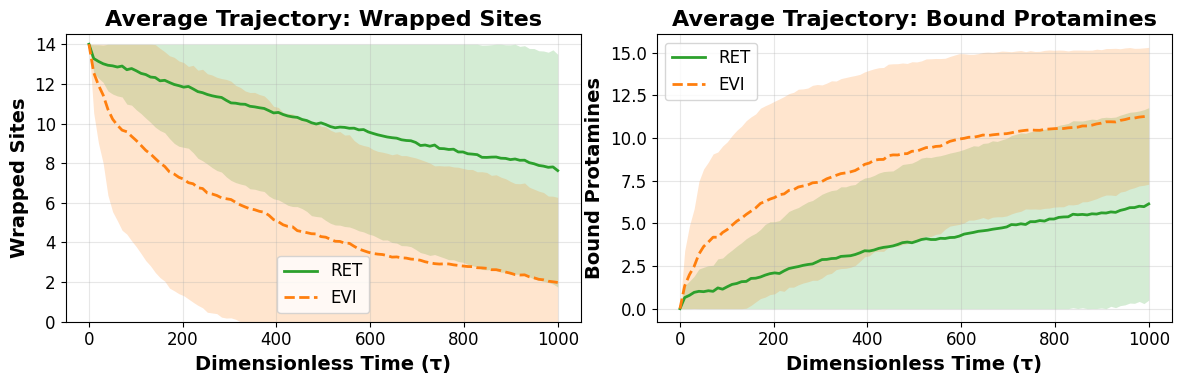

In [8]:
# Plot averaged trajectories with uncertainty bands
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Plot 1: Wrapped sites over time
ax = axes[0]
ax.fill_between(ret_tau_times, 
                np.clip(ret_avg_cs - ret_std_cs, 0, 14),
                np.clip(ret_avg_cs + ret_std_cs, 0, 14),
                color='tab:green', alpha=0.2, linewidth=0)
ax.plot(ret_tau_times, ret_avg_cs, label='RET', color='tab:green', lw=2)

ax.fill_between(evi_tau_times,
                np.clip(evi_avg_cs - evi_std_cs, 0, 14),
                np.clip(evi_avg_cs + evi_std_cs, 0, 14),
                color='tab:orange', alpha=0.2, linewidth=0)
ax.plot(evi_tau_times, evi_avg_cs, label='EVI', color='tab:orange', lw=2, ls='--')

ax.set_xlabel('Dimensionless Time (τ)')
ax.set_ylabel('Wrapped Sites')
ax.set_title('Average Trajectory: Wrapped Sites')
ax.set_ylim(0, 14.5)
ax.legend()
ax.grid(alpha=0.3)

# Plot 2: Bound protamines over time
ax = axes[1]
ax.fill_between(ret_tau_times,
                np.clip(ret_avg_bprot - ret_std_bprot, 0, 20),
                np.clip(ret_avg_bprot + ret_std_bprot, 0, 20),
                color='tab:green', alpha=0.2, linewidth=0)
ax.plot(ret_tau_times, ret_avg_bprot, label='RET', color='tab:green', lw=2)

ax.fill_between(evi_tau_times,
                np.clip(evi_avg_bprot - evi_std_bprot, 0, 20),
                np.clip(evi_avg_bprot + evi_std_bprot, 0, 20),
                color='tab:orange', alpha=0.2, linewidth=0)
ax.plot(evi_tau_times, evi_avg_bprot, label='EVI', color='tab:orange', lw=2, ls='--')

ax.set_xlabel('Dimensionless Time (τ)')
ax.set_ylabel('Bound Protamines')
ax.set_title('Average Trajectory: Bound Protamines')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Individual Nucleosome Trajectories

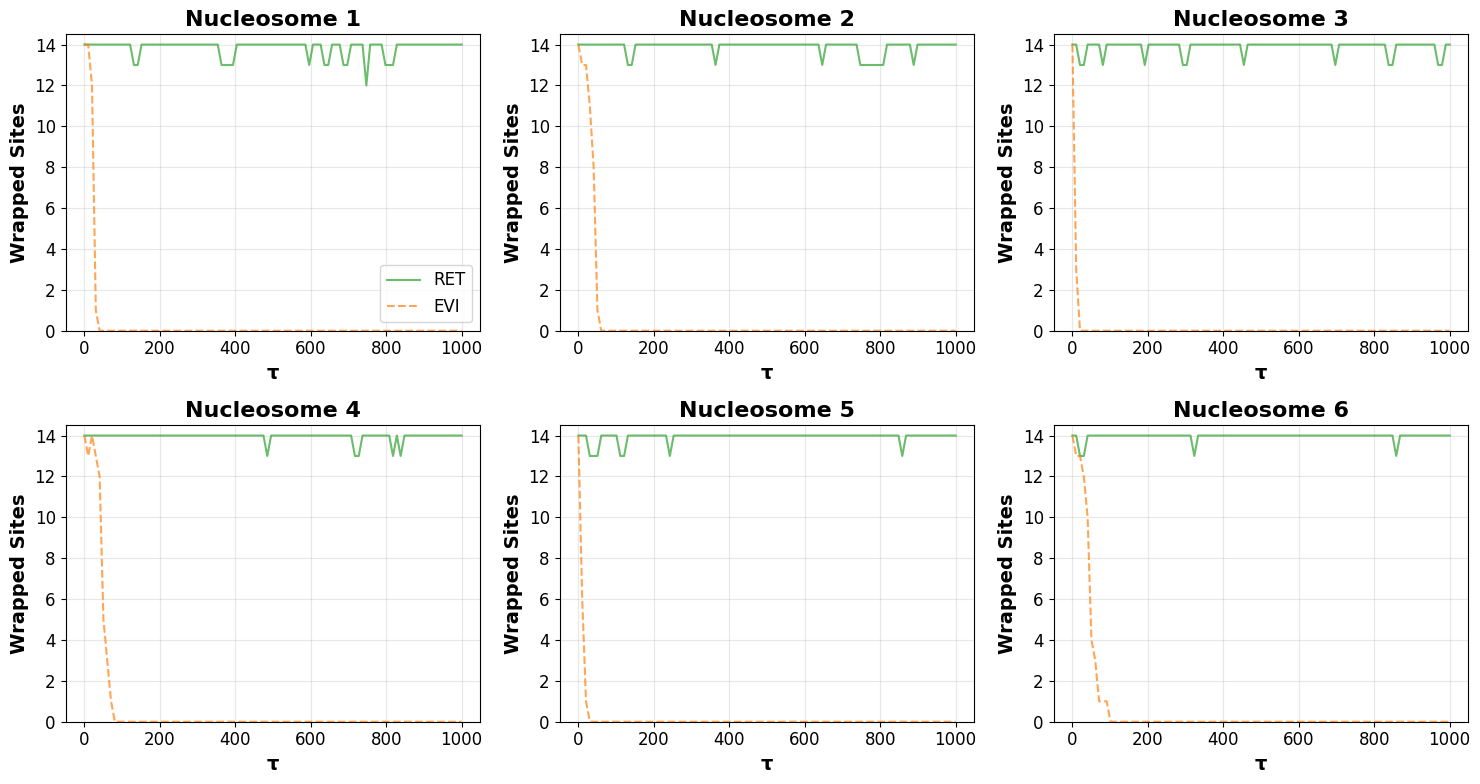

In [9]:
# Plot individual trajectories (first 6 nucleosomes)
n_plots = min(6, len(ret_cs_arrays))
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i in range(n_plots):
    ax = axes[i]
    
    # RET trajectory
    ax.plot(ret_tau_times, ret_cs_arrays[i], 
            label='RET', color='tab:green', lw=1.5, alpha=0.7)
    
    # EVI trajectory (if available)
    if i < len(evi_cs_arrays):
        ax.plot(evi_tau_times, evi_cs_arrays[i],
                label='EVI', color='tab:orange', lw=1.5, alpha=0.7, ls='--')
    
    ax.set_xlabel('τ')
    ax.set_ylabel('Wrapped Sites')
    ax.set_title(f'Nucleosome {i+1}')
    ax.set_ylim(0, 14.5)
    ax.grid(alpha=0.3)
    if i == 0:
        ax.legend()

plt.tight_layout()
plt.show()